In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from scipy import stats
from os.path import join
from pathlib import Path
import numpy as np
import pathlib
from typing import Dict, List

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
population_dict = {
    "ASW": "African Ancestry, USA",
    "ACB": "African Caribbean, Barbados",
    "BEB": "Bengali, Bangladesh",
    "GBR": "British, England and Scotland",
    "CDX": "Chinese Dai, China",
    "CLM": "Colombian, Colombia",
    "ESN": "Esan, Nigeria",
    "FIN": "Finnish, Finland",
    "GWD": "Gambian Mandinka, Gambia",
    "GIH": "Gujarati Indian, USA",
    "CHB": "Han Beijing, China",
    "CHS": "Han South, China",
    "IBS": "Iberian, Spain",
    "ITU": "Indian Telugu, UK",
    "JPT": "Japanese, Japan",
    "KHV": "Kinh, Vietnam",
    "LWK": "Luhya, Kenya",
    "MSL": "Mende, Sierra Leone",
    "MXL": "Mexican Ancestry, USA",
    "PEL": "Peruvian, Peru",
    "PUR": "Puerto Rican, Puerto Rico",
    "PJL": "Punjabi, Pakistan",
    "STU": "Sri Lankan Tamil, UK",
    "TSI": "Toscani, Italy",
    "YRI": "Yoruba, Nigeria"
}


In [4]:
from mylib import genomes


In [5]:
focused_population = "JPT" # Change this, for the paper, either ESN or GBR

In [6]:
all_populations = ["ESN", "ASW","ACB", "ITU", "BEB","GBR","CDX","CLM","KHV","FIN","GWD","GIH","CHB","CHS","IBS","JPT","LWK","MSL","MXL","PEL","PUR","PJL","STU","TSI","YRI"]

In [7]:
compared_populations = [p for p in all_populations if p != focused_population]

In [8]:
#indir = join(Path.home(),"projects/cp_als/populations")
root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/CD")
file_path = join(root_dir, f"{focused_population}/all.csv")
df = pd.read_csv(file_path)

In [9]:
all_genes = list(df['gene'].unique())

genes = [g for g in all_genes if g not in ["NOD2", "IL23R", "ATG16L1", "STAT3"]]
print(genes)
print(len(genes))

['ABCB1', 'ATG4C', 'CARD9', 'CDKAL1', 'DLG5', 'GPR35', 'HLA-DRB1', 'IL10', 'IL10RA', 'IL10RB', 'IL12B', 'IRF5', 'JAK2', 'KIF21B', 'LRRK2', 'MST1', 'NKX2-3', 'PTPN2', 'PTPN22', 'SLC22A4', 'SLC22A5', 'TLR4', 'TNF', 'TNFSF15', 'ZMIZ1']
25


In [10]:
populations = [c for c in genomes if c != focused_population]

In [11]:
hdf = pd.DataFrame(columns=populations,index=genes)
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,ESN,FIN,GBR,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
ABCB1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATG4C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CARD9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CDKAL1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DLG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPR35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-DRB1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL10RA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL10RB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
hdf = hdf.drop(index=["NOD2", "IL23R", "ATG16L1", "STAT3"], errors="ignore")
hdf.shape

(25, 24)

In [13]:
def get_total_variant_count(root_dir,important_gene,populations,genomes):
    total_variant_count = []
    for pop_name,genome_list in genomes.items():
        if pop_name not in populations:
            continue
        file_path = join(root_dir,f"{pop_name}/all.csv")
        df = pd.read_csv(file_path)
        df = df[df['gene'] == important_gene]
        filtered_genomes = [g for g in genome_list if g in df.columns]
        df_filtered = df[filtered_genomes]
        total_count = df_filtered.sum()
        total_variant_count.append(total_count.values)
    return total_variant_count

In [14]:
for important_gene in genes:
    for population in populations:
        population_pair = [focused_population, population]
        total_variant_count = get_total_variant_count(root_dir = root_dir, important_gene = important_gene,
                                                      populations = population_pair, genomes=genomes)
        t_statistic, p_value = stats.ttest_ind(total_variant_count[0],total_variant_count[1], equal_var=False)
        hdf.at[important_gene,population_pair[1]] = p_value

In [15]:
hdf.dropna(axis=1,how='all',inplace=True)

In [16]:
hdf.dropna(axis=0,how='any',inplace=True)

In [17]:
hdf.shape

(25, 24)

In [18]:
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,ESN,FIN,GBR,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
ABCB1,0.0,0.000007,0.022516,0.31771,0.390319,0.809357,0.46395,0.0,0.015484,0.062417,...,0.768539,0.0,0.0,0.669169,0.240292,0.211312,0.623532,0.00685,0.136971,0.0
ATG4C,0.000032,0.000136,0.514952,0.976273,0.842519,0.394479,0.051922,0.0,0.216823,0.008162,...,0.577532,0.0,0.0,0.223365,0.000234,0.134795,0.000077,0.763092,0.212431,0.0
CARD9,0.067753,0.168367,0.206249,0.002766,0.95931,0.752833,0.000003,0.041098,0.289412,0.134729,...,0.120219,0.052525,0.190231,0.001113,0.0,0.195845,0.001757,0.203117,0.113509,0.159764
CDKAL1,0.0,0.0,0.641137,0.965118,0.399616,0.866809,0.100188,0.0,0.229237,0.929651,...,0.287958,0.0,0.0,0.455419,0.653475,0.71946,0.02056,0.273344,0.786684,0.0
DLG5,0.117083,0.373198,0.828841,0.583579,0.825906,0.782772,0.17341,0.182695,0.705076,0.849984,...,0.895474,0.896253,0.083027,0.016582,0.005926,0.764616,0.170761,0.627415,0.00337,0.047522
GPR35,0.0,0.0,0.015193,0.784556,0.269565,0.180022,0.0,0.0,0.0,0.0,...,0.736435,0.0,0.0,0.0,0.0,0.0,0.0,0.001709,0.0,0.0
HLA-DRB1,0.99238,0.695384,0.78697,0.940288,0.918865,0.456727,0.003768,0.149866,0.000048,0.125143,...,0.732812,0.422353,0.814738,0.449839,0.176551,0.00503,0.0789,0.135742,0.420504,0.090007
IL10,0.0,0.000001,0.000023,0.315706,0.023451,0.839994,0.0,0.0,0.0,0.0,...,0.747978,0.0,0.0001,0.0,0.0,0.0,0.0,0.000337,0.0,0.0
IL10RA,0.000346,0.001332,0.000027,0.101142,0.001069,0.00523,0.0,0.020216,0.0,0.0,...,0.046757,0.0,0.004353,0.0,0.000015,0.0,0.0,0.0,0.0,0.012938
IL10RB,0.009873,0.013583,0.053133,0.002666,0.271527,0.08623,0.677377,0.000016,0.121252,0.736371,...,0.009791,0.016059,0.000006,0.718768,0.003933,0.231164,0.789862,0.912772,0.542538,0.000244


In [19]:
hdf.columns

Index(['ACB', 'ASW', 'BEB', 'CDX', 'CHB', 'CHS', 'CLM', 'ESN', 'FIN', 'GBR',
       'GIH', 'GWD', 'IBS', 'ITU', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL',
       'PUR', 'STU', 'TSI', 'YRI'],
      dtype='object')

In [20]:
hdf_float = hdf.apply(pd.to_numeric,errors='coerce')

In [21]:
hdf_rounded = hdf_float.round(3)
hdf_rounded = hdf_rounded[compared_populations]
hdf_rounded.shape

(25, 24)

In [22]:
# Define mapping
pop_to_continent = {
    # Africa
    "ACB": "Africa",
    "GWD": "Africa",
    "LWK": "Africa",
    "MSL": "Africa",
    "YRI": "Africa",
    "ASW": "Africa",
    "ESN": "Africa",
    
    # Americas
    "CLM": "Americas",
    "MXL": "Americas",
    "PEL": "Americas",
    "PUR": "Americas",

    # East Asia
    "CDX": "East Asia",
    "CHB": "East Asia",
    "CHS": "East Asia",
    "JPT": "East Asia",
    "KHV": "East Asia",

    # Europe
    "FIN": "Europe",
    "GBR": "Europe",
    "IBS": "Europe",
    "TSI": "Europe",

    # South Asia
    "BEB": "South Asia",
    "GIH": "South Asia",
    "ITU": "South Asia",
    "PJL": "South Asia",
    "STU": "South Asia",
}

In [23]:
pop_to_continent.pop(focused_population, None)

'East Asia'

In [24]:
compared_populations_sorted = sorted(compared_populations, key=lambda x: pop_to_continent[x])
hdf_rounded = hdf_rounded[compared_populations_sorted]
continent_order = [pop_to_continent[p] for p in compared_populations_sorted]

In [25]:
from matplotlib.colors import BoundaryNorm

bounds = [0,0.051,0.1,0.5,0.75,1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)
norm = BoundaryNorm (boundaries=bounds,ncolors = cmap.N)

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_35962/722416586.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)


In [26]:
selected_genes = ["TNF", "TLR4", "MST1"] # "STAT3", "CARD9",  "JAK2", , "DLG5"

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_35962/53718046.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = hdf_subset.applymap(format_value)
/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_35962/53718046.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds) - 1)


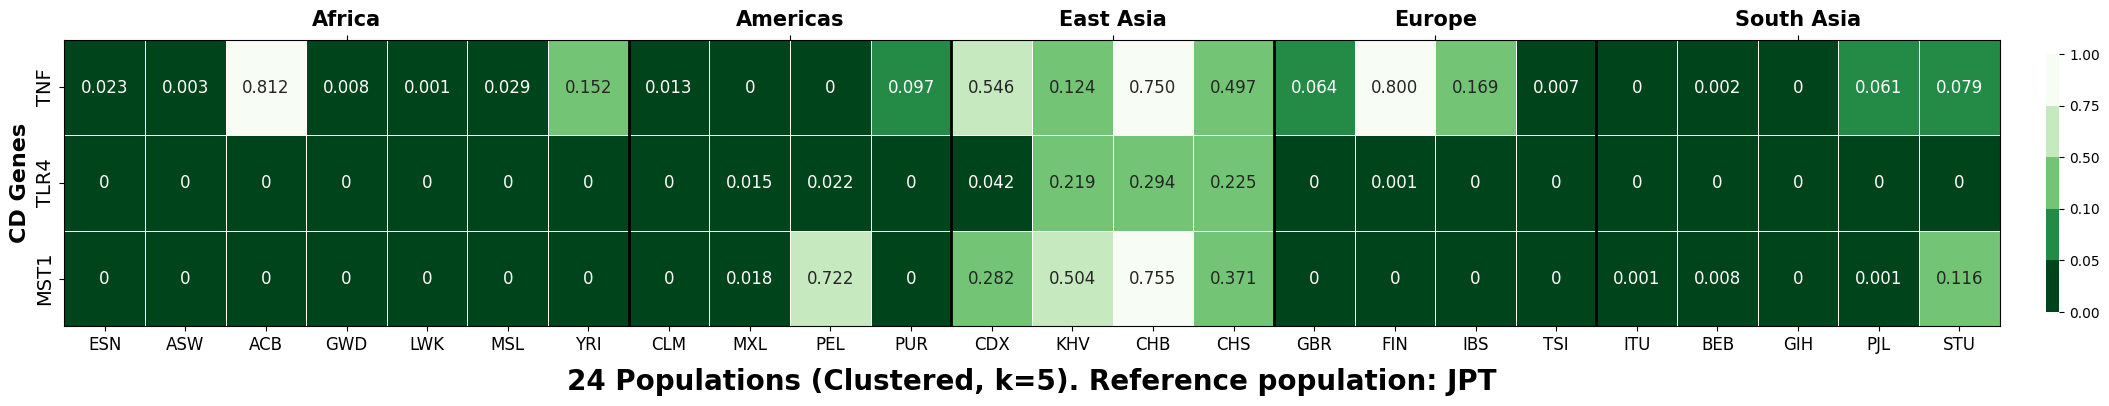

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import BoundaryNorm

# -----------------------------------
# Filter to selected genes
# -----------------------------------

hdf_subset = hdf_rounded.loc[selected_genes]

# -----------------------------------
# Format annotations: 0.0000 → "0"
# -----------------------------------
def format_value(x):
    if np.isclose(x, 0):
        return "0"
    return f"{x:.3f}"

annot_data = hdf_subset.applymap(format_value)

# -----------------------------------
# Create folder if needed
# -----------------------------------
os.makedirs("plots", exist_ok=True)

# -----------------------------------
# Plot (wide for full LaTeX width)
# -----------------------------------
plt.figure(figsize=(24, 4))  # wider + shorter

bounds = [0, 0.051, 0.1, 0.5, 0.75, 1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

ax = sns.heatmap(
    hdf_subset,
    cmap=cmap,
    norm=norm,
    annot=annot_data,
    fmt="",
    annot_kws={"size": 12},
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.9, "pad": 0.02}
)

# -----------------------------------
# Vertical continent separators
# -----------------------------------
boundaries = [
    i for i in range(1, len(continent_order))
    if continent_order[i] != continent_order[i - 1]
]

for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# -----------------------------------
# Continent labels on top
# -----------------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

group_positions = []
group_labels = []

for cont, pops in pd.Series(continent_order).groupby(continent_order):
    mid = (pops.index[0] + pops.index[-1]) / 2
    group_positions.append(mid + 0.5)
    group_labels.append(cont)

ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_labels, fontsize=15, fontweight="bold")

# -----------------------------------
# Axis labels (NO TITLE)
# -----------------------------------
ax.set_xlabel(
    # f"{hdf_subset.shape[1]} Populations (Clustered, k=5)",
    f"{hdf_subset.shape[1]} Populations (Clustered, k=5). Reference population: {focused_population}",

    fontsize=20,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "CD Genes",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=14)

# -----------------------------------
# Layout tuning for LaTeX
# -----------------------------------
plt.tight_layout(pad=0.5)

# -----------------------------------
# Save (PDF > PNG for LaTeX)
# -----------------------------------
# output_file = f"plots/cd_major_genes_heatmap_{focused_population}.pdf"
# plt.savefig(output_file, bbox_inches="tight")
# output_file = "plots/figure_8.png"
# plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
# plt.close()

# print(f"Saved: {output_file}")
plt.show()